# HOME LOAN APPROVAL ANALYSIS

 # OBJECTIVES OF ANALYSIS:

1. Gain familiarity with the dataset.  
2. Perform data exploration and visualization.
3. Identify patterns, trends, and potential insights.
4. Generate meaningful visualizations to
 communicate your findings

# Project Flow: -

Step 1: Installation and Importing of Libraries

Step 2: Data Collection and Loading

Step 3: Basic Data Inspection

Step 4: Data Cleaning and Pre Processing

Step 5: Exploratory Data Analysis and Visualization

Step 6. Findings

Step 7:Recommendations

# Task 1: Data Exploration

Step 1: Installation and Importing of Libraries

Step 2: Data Collection and Loading

Step 3: Basic Data Inspection

In [254]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [255]:
#IMPORTING LIBRARIES
import os ## optional library - used to import paths for different files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [256]:
# Load the dataset into a Python environment
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EDA DATASETS/loan_sanction_test.csv')

In [257]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [258]:
df.shape
rows=df.shape[0]
cols=df.shape[1]
print(f"The dataset has {rows} rows and {cols} columns")

The dataset has 367 rows and 12 columns


In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [260]:
#Summarize basic statistics (mean, median, standard deviation, etc.) for the numeric columns
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


# Task 2: Data Pre Processing

Step 4: Data Cleaning and Pre Processing

In [261]:
df.duplicated().sum()

np.int64(0)

In [262]:
df.drop_duplicates(inplace=True)

In [263]:
df.shape

(367, 12)

1.  Handling Missing Values

In [264]:
df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


<Axes: >

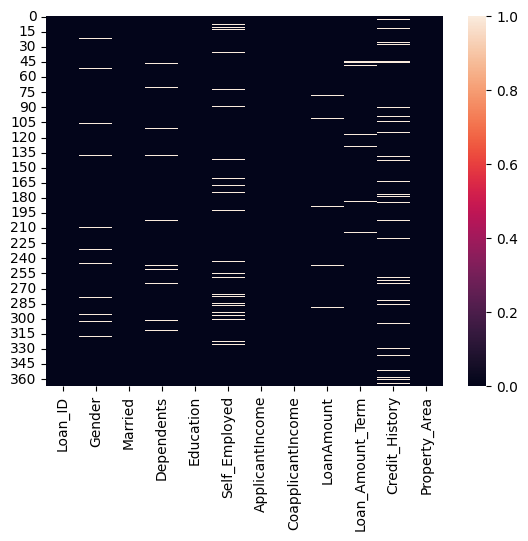

In [265]:
#visualization of missing values
sns.heatmap(df.isnull())

## Handling missing values - we will check the percentage of missing values:-

- if missing values are greater than 25% we will drop the column (default you are domain expert)
- if less than 25% values are missing then we will cap the values using statistical method

In [266]:
#percentage
(df.isnull().sum()/len(df))*100

,0
Loan_ID,0.000000
Gender,2.997275
Married,0.000000
Dependents,2.724796
Education,0.000000
Self_Employed,6.267030
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,1.362398
Loan_Amount_Term,1.634877


 Since, all are less than 25% hence have to deal with missing values by replacing categorical with mode and numerical with either mean or median depending on presence of Outliers.
 Categorical : Gender, Self Employed,‘Dependents’
 Numerical : LoanAmount,Loan_Amount_Term, Credit_History

In [267]:
list_of_cats=['Gender','Self_Employed']
for i in list_of_cats:
  df[i]=df[i].fillna(df[i].mode()[0])

In [268]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,10
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [269]:
# Replace '3+' with 3
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(float)

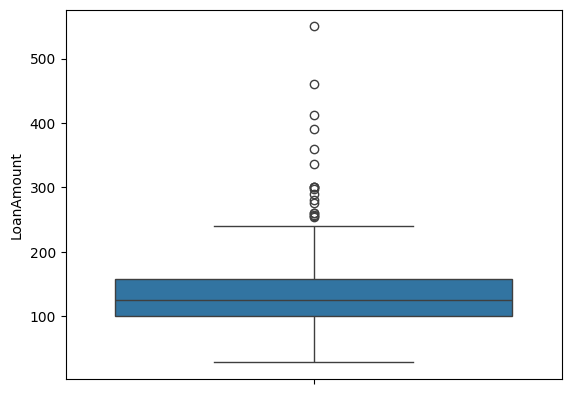

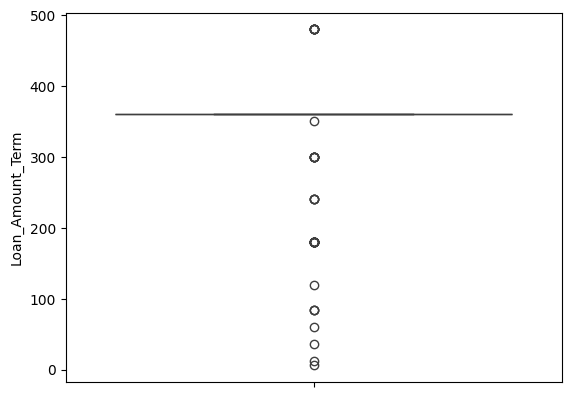

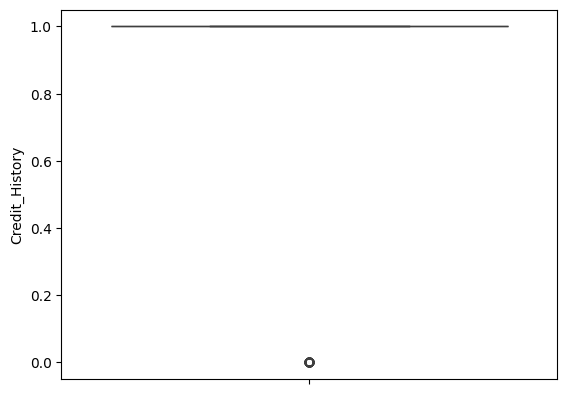

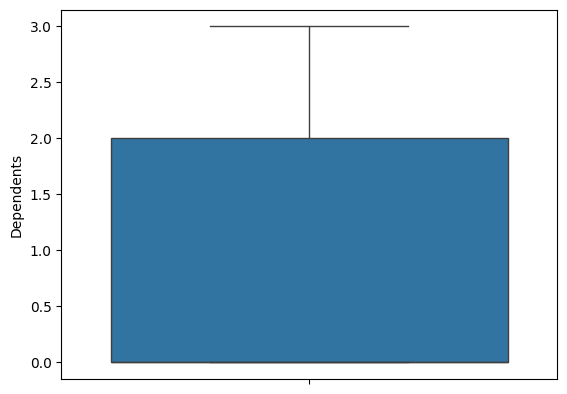

In [270]:
#for numerical dtypes, checking outliers
list_of_nums=['LoanAmount','Loan_Amount_Term','Credit_History','Dependents']
for i in list_of_nums:
  sns.boxplot(df[i])
  plt.show()

In [271]:
#There are outliers, hence filling the missing values with median
list_of_nums=['LoanAmount','Loan_Amount_Term','Credit_History','Dependents']
for i in list_of_nums:
  df[i]=df[i].fillna(df[i].median())

In [272]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [273]:
## Handling outliers: IQR method
list_of_nums=['LoanAmount','Loan_Amount_Term','Credit_History']
for i in list_of_nums:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    print(f"Q1:{q1}")
    print(f"Q3:{q3}")
    print(f"IQR:{iqr}")

Q1:101.0
Q3:157.5
IQR:56.5
Q1:360.0
Q3:360.0
IQR:0.0
Q1:1.0
Q3:1.0
IQR:0.0


In [274]:
## formulate UL and lower LL
UL = q3+1.5*iqr
LL = q1-1.5*iqr
df[i] = np.where(df[i]>UL,UL,
                    np.where(df[i]<LL,LL,
                            df[i]))

<Axes: >

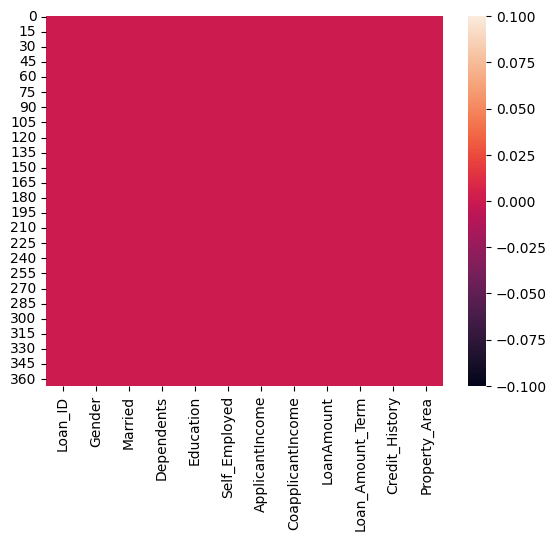

In [275]:
#visualization of after handling missing values
sns.heatmap(df.isnull())

There is a huge difference between 75% quantile and Max value in two columns : Applicant Income
Co-Applicant Income
which signifies presence of outliers hence, handling them as well.

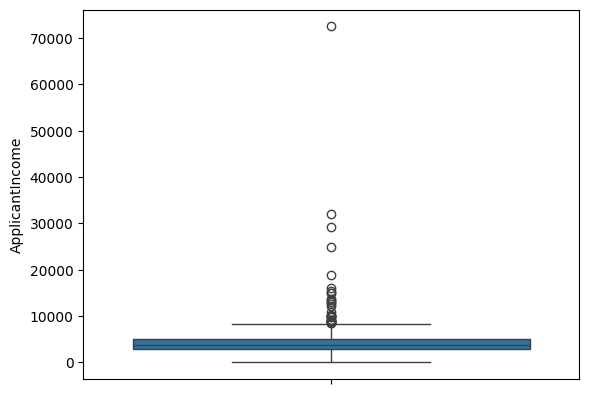

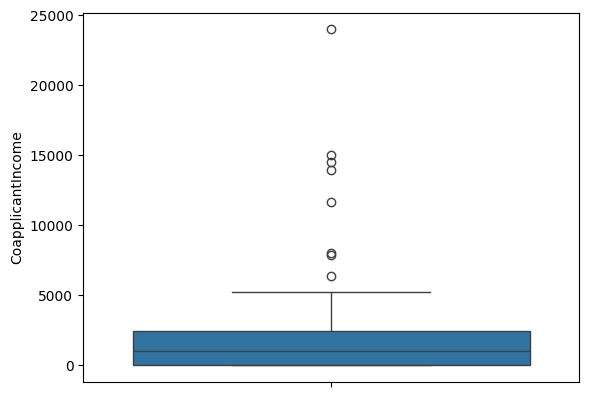

In [276]:
list_of_po=['ApplicantIncome','CoapplicantIncome']
for i in list_of_po:
  sns.boxplot(df[i])
  plt.show()

In [277]:
list_of_po=['ApplicantIncome','CoapplicantIncome']
for i in list_of_po:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  UL=q3+1.5*iqr
  LL=q1-1.5*iqr
  df[i]=np.where(df[i]>UL,UL,
                 np.where(df[i]<LL,LL,
                          df[i]))

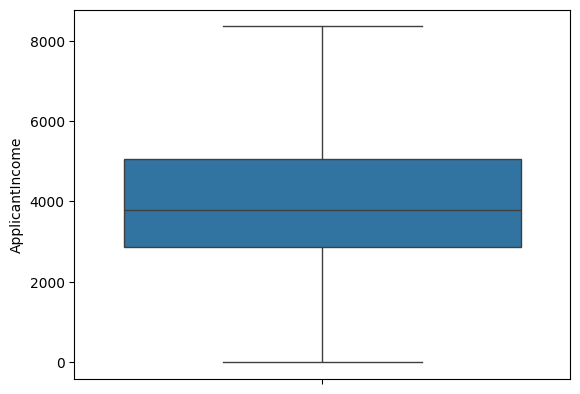

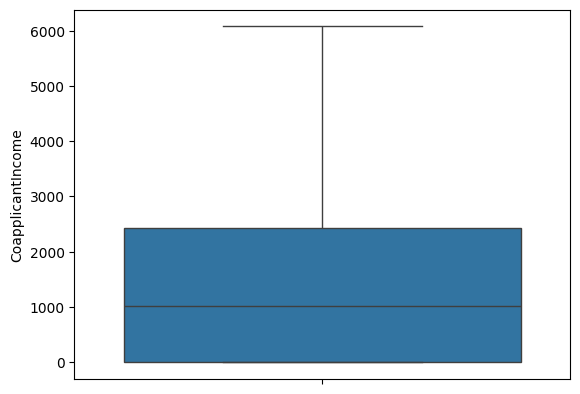

In [278]:
list_of_po=['ApplicantIncome','CoapplicantIncome']
for i in list_of_po:
  sns.boxplot(df[i])
  plt.show()

In [279]:
df['Credit_History'] = df['Credit_History'].astype(int)

In [280]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].astype(int)

 # Task 2: Data Visualization

(Step 5: Exploratory Data Analysis and Visualization)


# 2.1 Univariate Analysis

 Explore the distribution of numeric columns
 using the following visualizations:  

# Histograms: Plot the frequency distribution of key numeric variables

In [281]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,float64
Education,object
Self_Employed,object
ApplicantIncome,float64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,int64


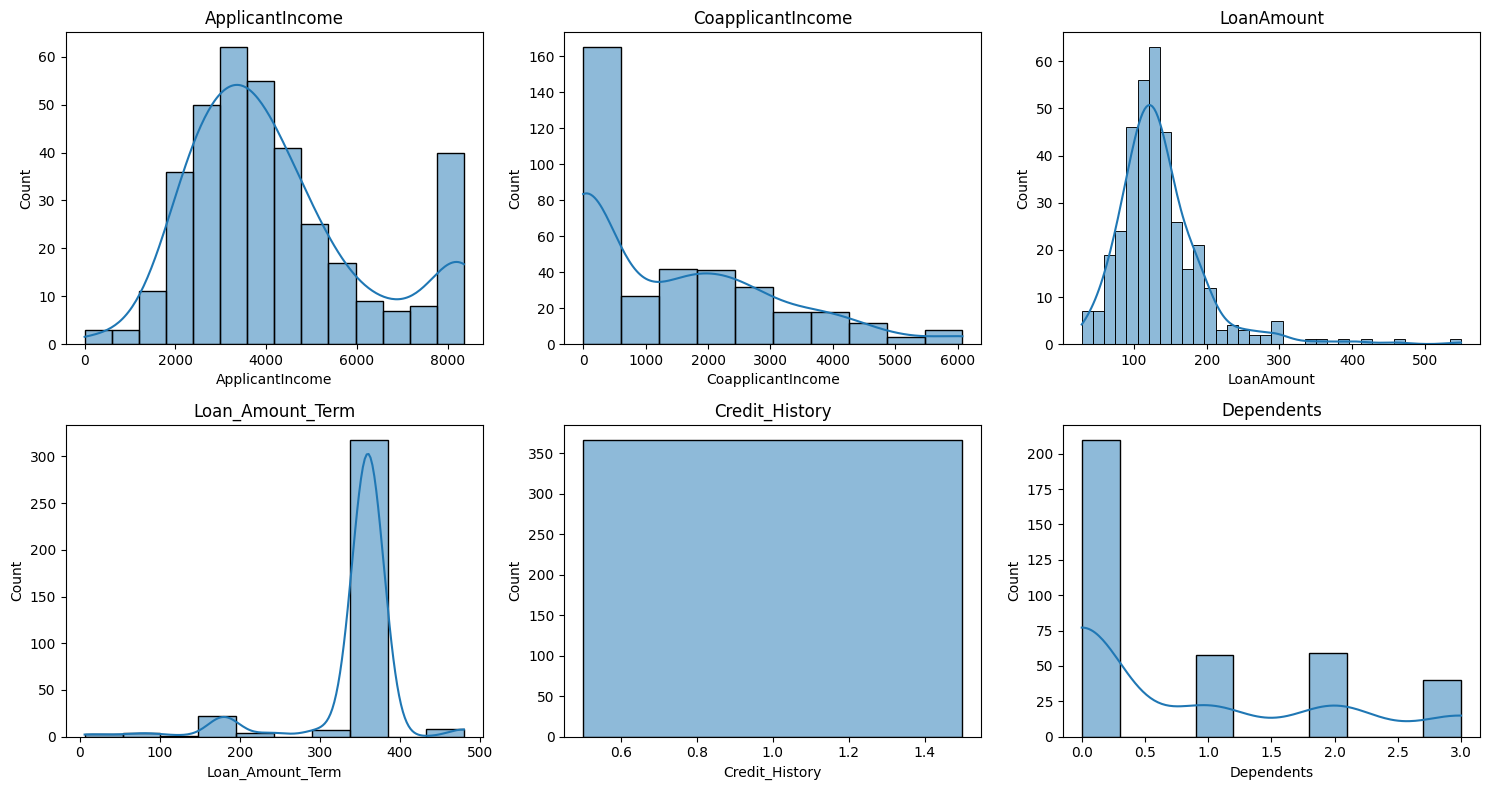

In [282]:
list_of_numerical = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History','Dependents']

# Set up 2 rows and 3 columns for subplots
plt.figure(figsize=(15, 8))

for i, col in enumerate(list_of_numerical):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


Insights:

1. Applicant Income
The distribution is right-skewed, meaning most applicants have relatively low incomes.

This suggests that a large portion of loan seekers fall into a lower-income bracket, which can influence loan amounts and approval chances.

2. Co-applicant Income
Like the applicant income, this distribution is heavily right-skewed.

Most co-applicants earn less than ₹5,000, indicating limited financial contribution from secondary applicants in many cases.

3. Loan Amount
The loan amount distribution is moderately right-skewed.

A large number of applicants request loans in the ₹100–₹200K range, highlighting the typical affordability level and common loan expectations.

4. Loan Amount Term
The majority of loan terms are clustered around 360 months (30 years).

This implies that most applicants prefer long-term repayment plans, possibly for home purchases or larger investments.

5. Credit History
The histogram shows a clear divide between applicants with and without a valid credit history (values mostly 1 or 0).

A good credit history (1) is far more frequent, reaffirming its importance in loan approvals.

6. Dependents
Most applicants report having 0 to 2 dependents, with '3+' being less common.

This reflects the typical family size of applicants, which can affect financial obligations and loan eligibility.



# Box Plots: Identify potential outliers and visualize the spread of data

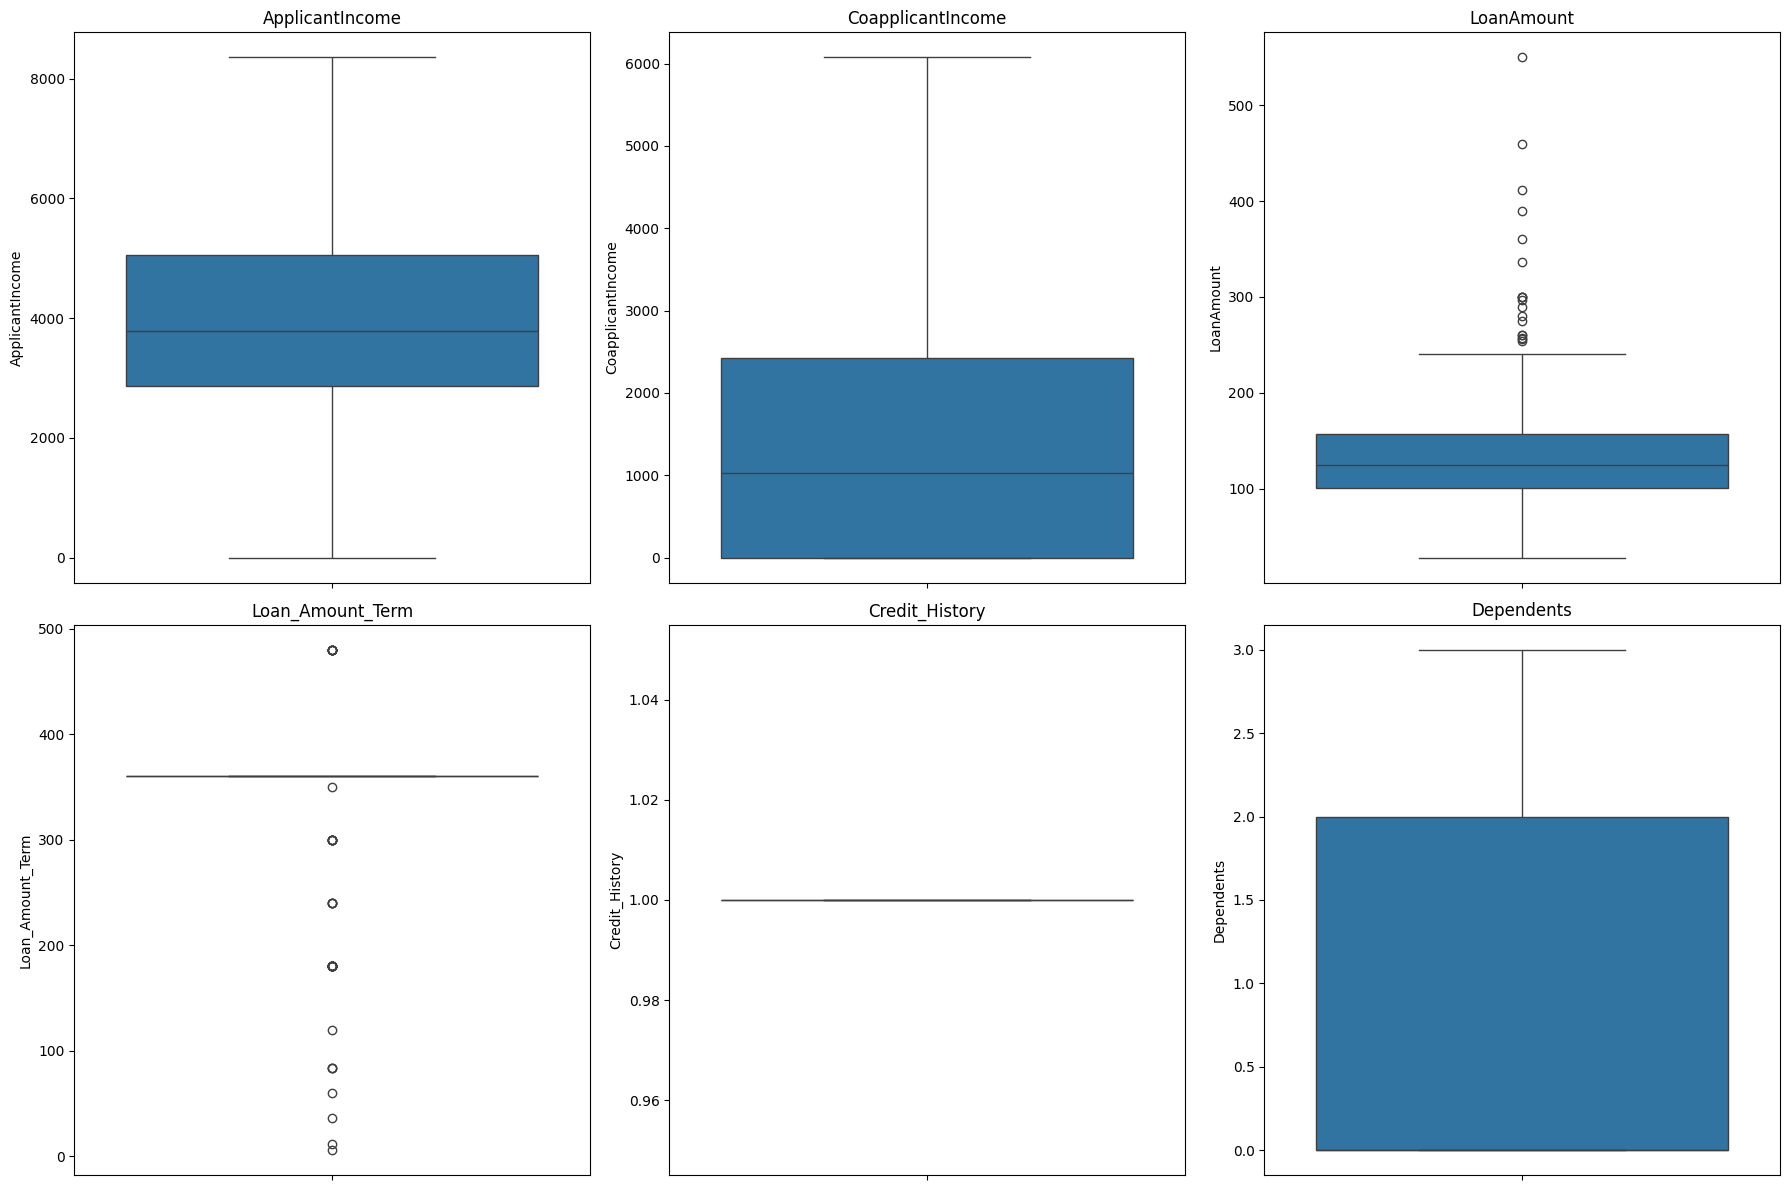

In [283]:
list_of_numerical = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History','Dependents']

plt.figure(figsize=(18,12))
for i, col in enumerate(list_of_numerical):
  plt.subplot(2,3,i+1)
  sns.boxplot(df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

ApplicantIncome: The distribution is right-skewed with most applicants having lower incomes.

Several high-income outliers are present, indicating a few applicants earn significantly more than the average.

CoapplicantIncome: A large number of entries are around zero, suggesting many applicants have no co-applicant or co-applicants without income.

Outliers are evident, with some co-applicants earning substantially higher than the typical range.

LoanAmount: The loan amounts are mostly concentrated between 100 to 250 (likely in thousands), showing common loan preferences.

Clear presence of outliers above 300–400, indicating a minority requesting much larger loans.

Loan_Amount_Term: The most frequent term is 360 months, showing a preference for long-term loans (likely mortgages).

A few outliers exist at very short or extremely long durations, which are less common among applicants.

Credit_History: Very limited variation; most applicants have a credit history value of 1.

This indicates that the majority are considered creditworthy, with no significant outliers visible.

Dependents: Most applicants report 0 to 2 dependents.

Values like "3+" converted to 3 do not indicate outliers, but suggest a moderately increasing family responsibility.


Analyze categorical variables by creating the
following plots:

# Bar Charts: Visualize the frequency distribution of categorical variables.

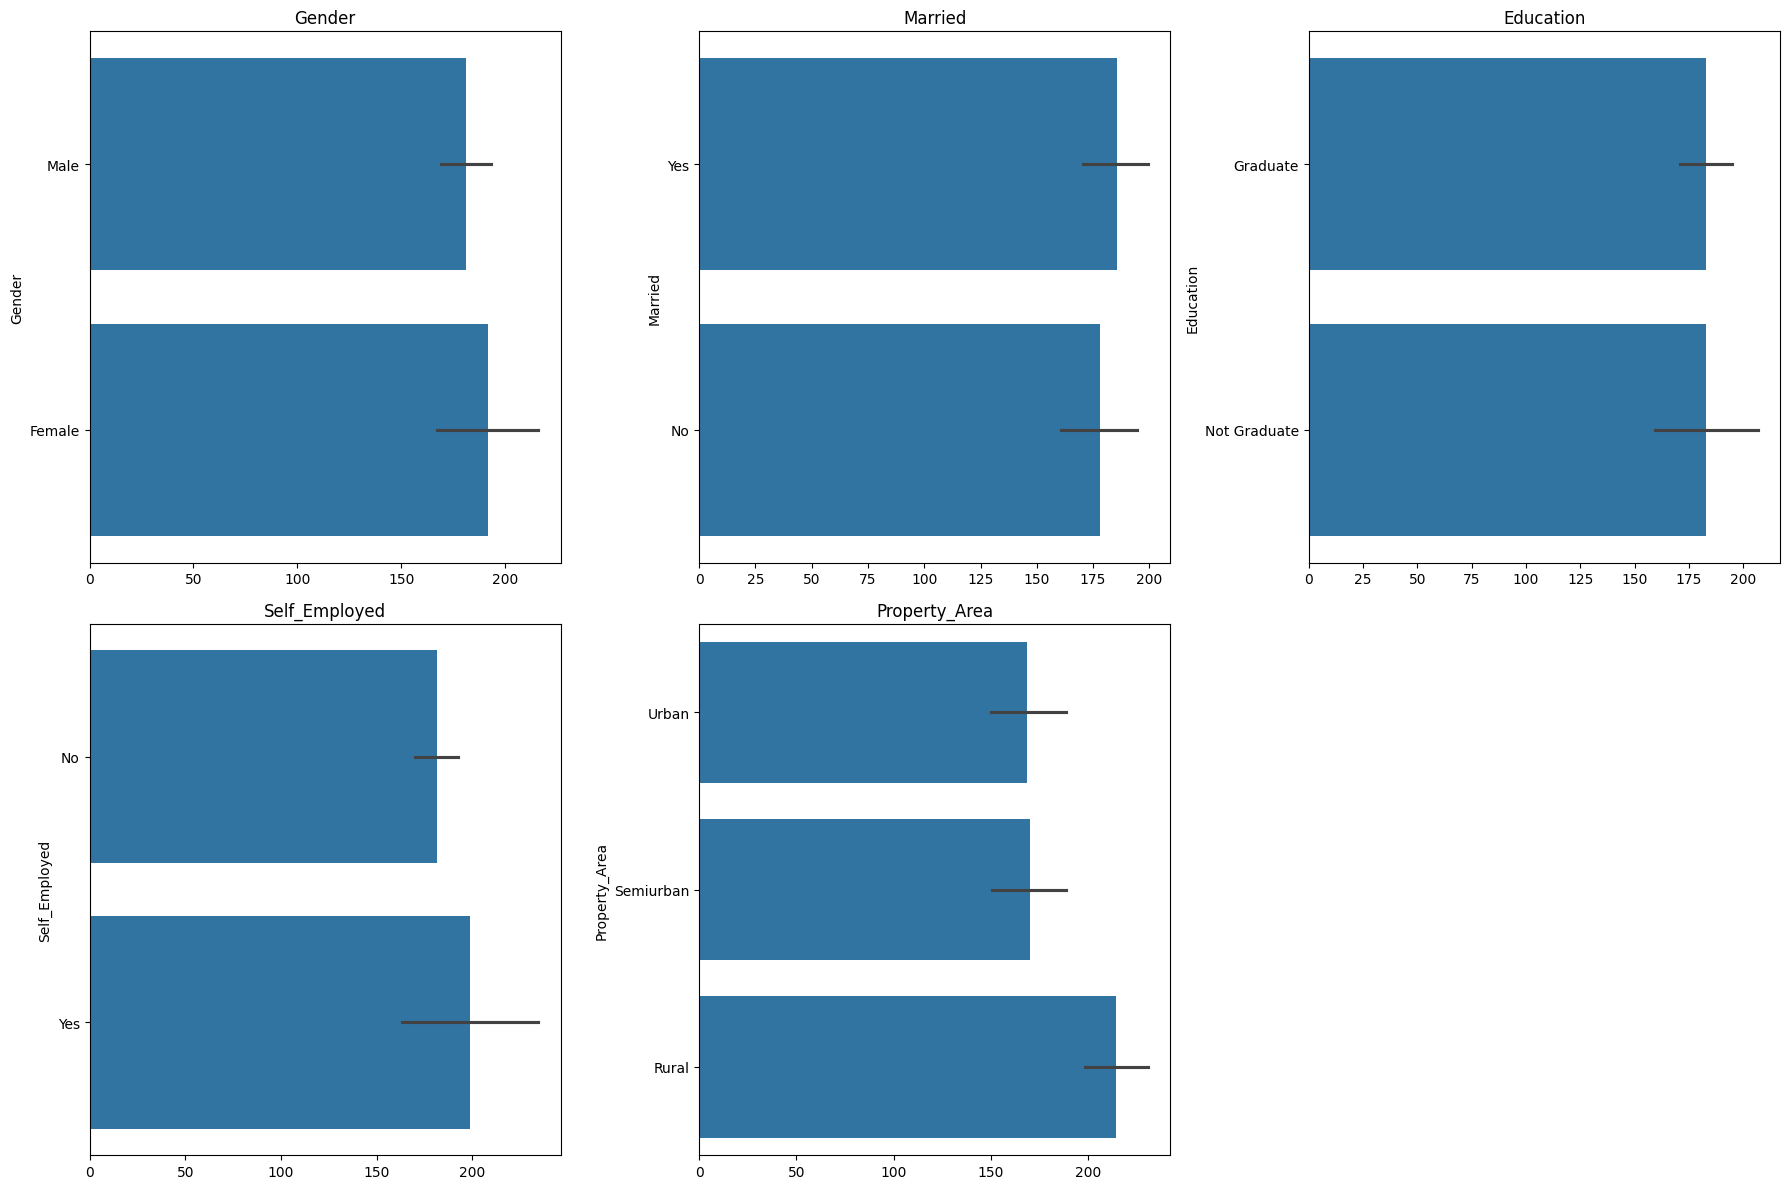

In [284]:
list_of_categorical=['Gender','Married','Education','Self_Employed','Property_Area']
plt.figure(figsize=(18,12))
for i, col in enumerate(list_of_categorical):
  plt.subplot(2,3,i+1)
  sns.barplot(df[col])
  plt.title(col)
plt.tight_layout()
plt.show()


However, as per question of the project given, it is not an appropirate way to show count of each value, hence, plotting Count plot

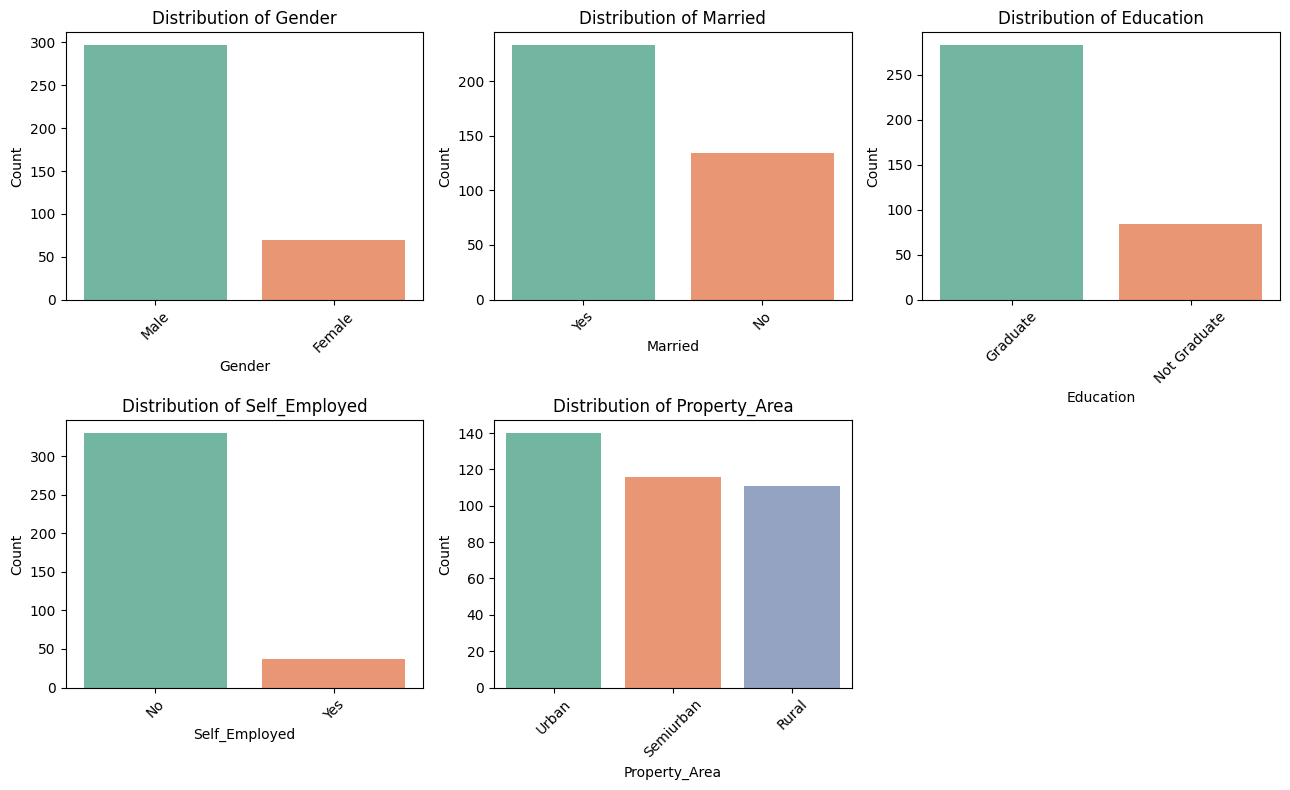

In [285]:
list_of_categorical = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

plt.figure(figsize=(13, 8))
for i, col in enumerate(list_of_categorical):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Insights:
1. Gender: Most loan applicants are male, suggesting either a gender-based application preference or greater financial responsibility taken by males in households.

2. Married: A large proportion of applicants are married, indicating that married individuals may have higher loan demands—possibly due to shared responsibilities or long-term financial planning.

3. Education: The majority of loan applicants are graduates. This may imply that higher education correlates with greater financial literacy or access to loan opportunities.

4. Self-Employed: Most applicants are not self-employed. This suggests that salaried individuals are more likely to apply for loans, possibly due to more stable and verifiable incomes.

5. Property Area: Applications are fairly well distributed across urban, semi-urban, and rural areas, with a slightly higher share in semi-urban regions. This reflects widespread housing needs across all area types.

# Pie Charts: Represent the composition of categorical variables

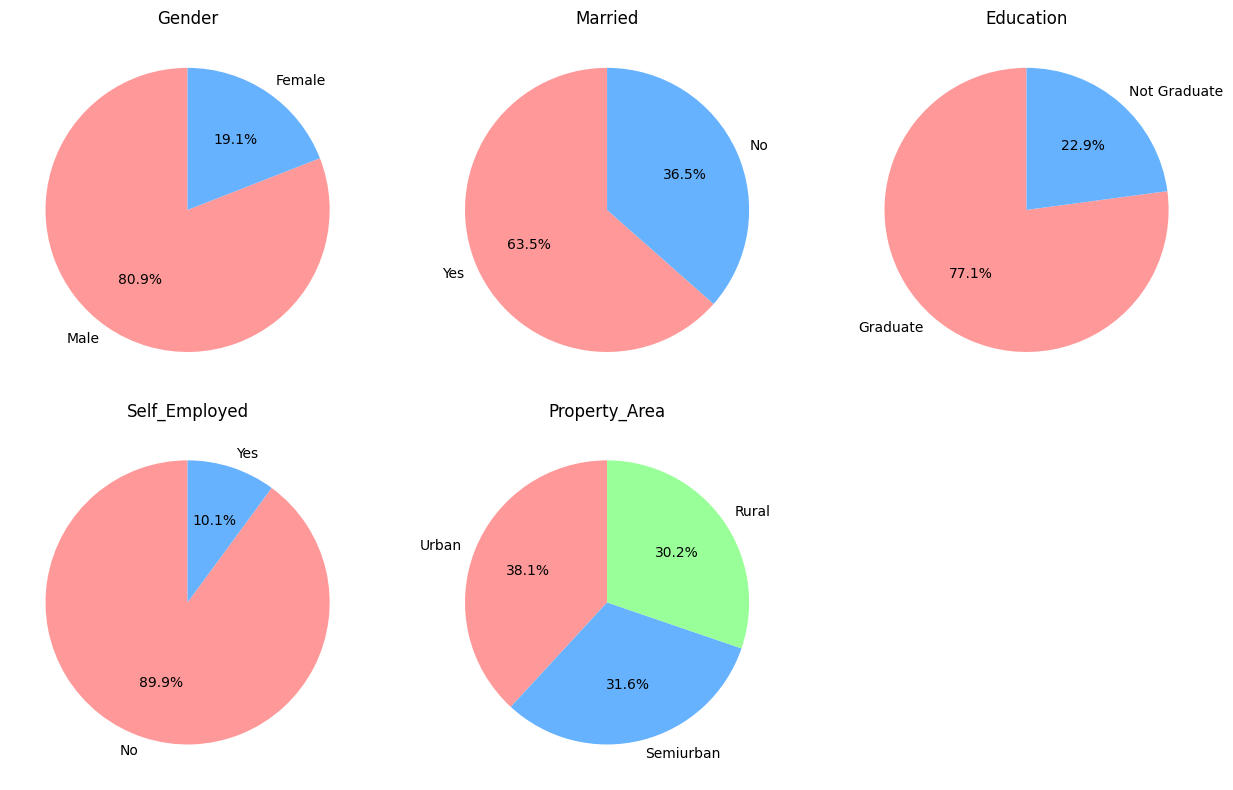

In [286]:
list_of_categorical = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

plt.figure(figsize=(13, 8))
for i, col in enumerate(list_of_categorical):
    plt.subplot(2, 3, i + 1)
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
    plt.pie(df[col].value_counts(), labels=df[col].unique(), autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(col)

plt.tight_layout()
plt.show()

Insights:

1. Gender Distribution: Around 81%(80.9%) of the loan applicants are male, indicating a significant gender imbalance in loan
applications.

2.Marital Status Distribution: Approximately 63.5% of the applicants are married, suggesting that married individuals may be more likely to apply for loan due to shared responsibilites.

3. Education Distribution: A majority (around 77%) of the applicants are graduates, indicating a higher likelihood of loanapplications from individuals with higher education levels, also people not graduated yet, may likely have less financial or family burden.

4. Self-Employed Distribution: Only about 10% of the applicants are self-employed, while about 89% employed, which implys that a majority of loan
applications come from salaried individuals also more chances of loan repay at stipulated tenure.

5. Property Area Distribution: The distribution of applicants across property areas (Semiurban, Urban, Rural) is relatively balanced, with Urban and Semiurban areas have a competitive equivalent demand, and Urban with slightly higher.

# 2.2 Bivariate Analysis

# Create scatter plots to explore relationships between pairs of numeric variables.   

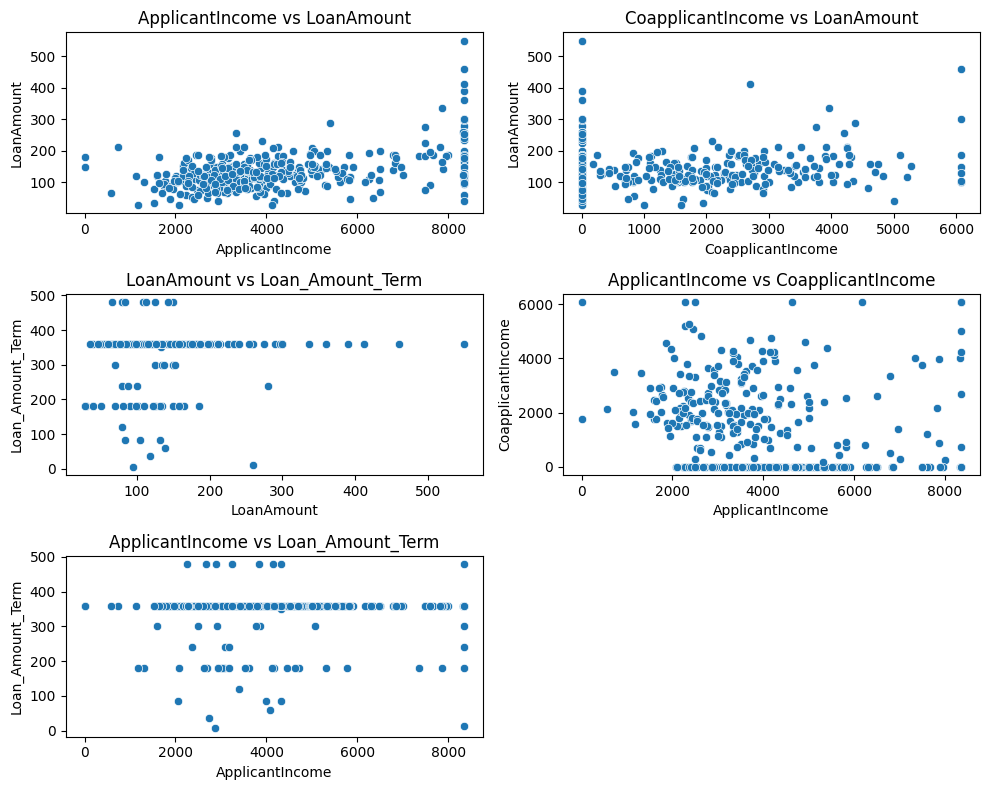

In [287]:
numeric_pairs = [
    ('ApplicantIncome', 'LoanAmount'),
    ('CoapplicantIncome', 'LoanAmount'),
    ('LoanAmount', 'Loan_Amount_Term'),
    ('ApplicantIncome', 'CoapplicantIncome'),
    ('ApplicantIncome', 'Loan_Amount_Term')
]

plt.figure(figsize=(10, 8))

# Loop to create scatter plots
for i, (x, y) in enumerate(numeric_pairs):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f'{x} vs {y}')

plt.tight_layout()
plt.show()


Insights:

1. ApplicantIncome vs LoanAmount: Weak positive trend observed where igher applicant income slightly corresponds to higher loan amounts which means some high-income applicants still request small loans.

2. CoapplicantIncome vs LoanAmount:No strong visible correlation. Many co-applicants have zero income, suggesting they may not influence loan amount significantly.

3. LoanAmount vs Loan_Amount_Term: Most loan terms cluster around 360 months regardless of the loan amount.

4. ApplicantIncome vs CoapplicantIncome: Majority of applicants have either high applicant income or co-applicant income, not both.

5. ApplicantIncome vs Loan_Amount_Term: No clear relationship.

# Use pair plots (scatter matrix) to visualize interactions between multiple numeric variables simultaneously.

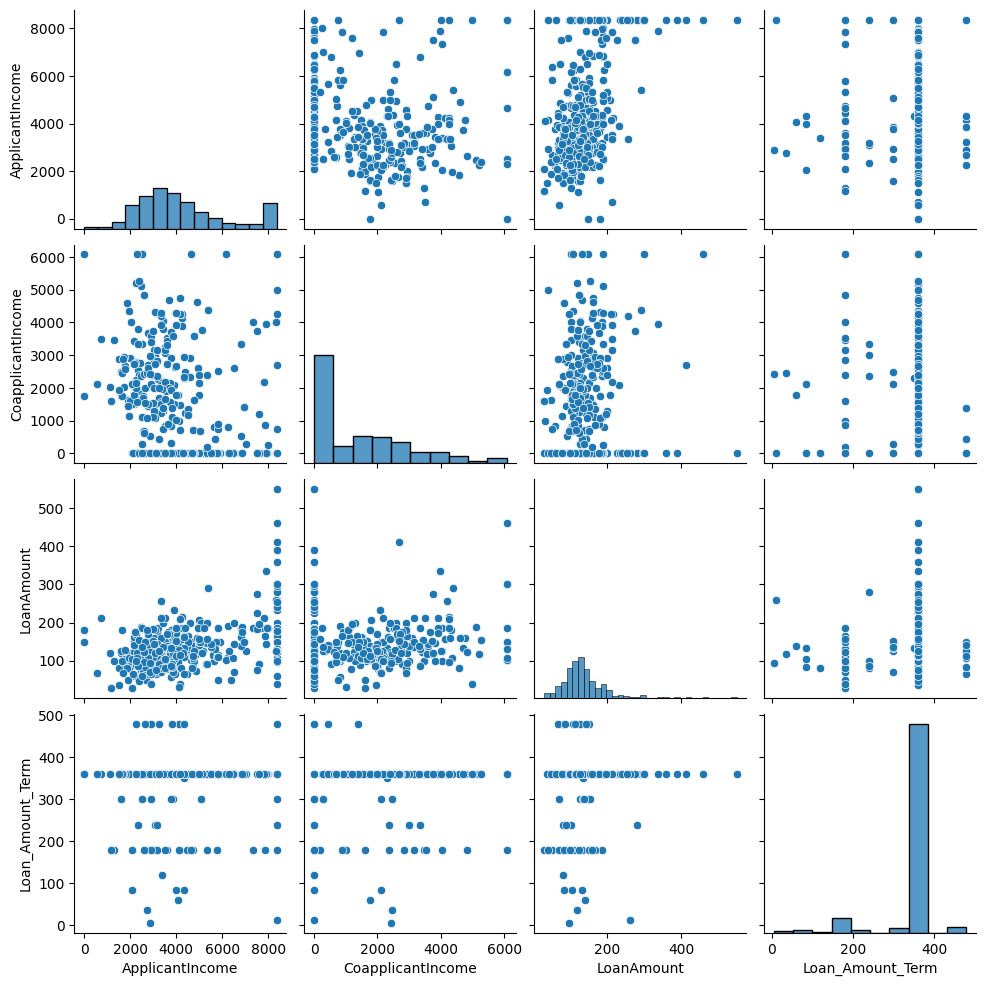

In [288]:
sns.pairplot(df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']])

# Show plot
plt.show()

Insights:

Applicant Income vs Loan Amount: A positive correlation exists, meaning that as 'Applicant Income' rises, the 'Loan Amount' they qualify for also tends to increase.

Co-applicant Income vs Loan Amount: No significant correlation is observed. The 'Loan Amount' does not appear to be strongly influenced by 'Co-applicant Income'.

Loan Amount vs Loan Amount Term: No clear correlation is found. The loan duration does not seem to have a strong relationship with the loan amount.

#Investigate the relationship between categorical and numeric variables using box plots or violin plots

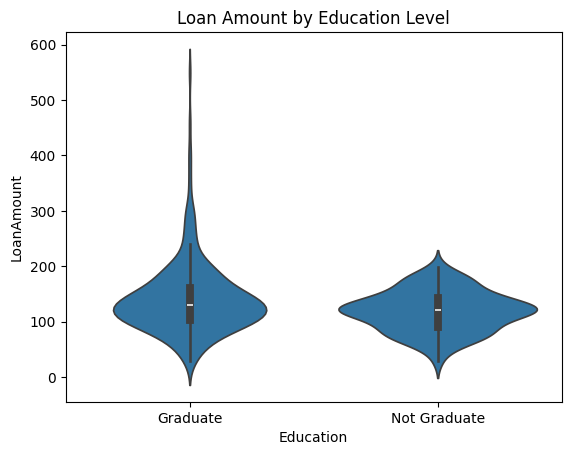

In [289]:
# Violin plot: LoanAmount vs Education
sns.violinplot(x='Education', y='LoanAmount', data=df)
plt.title('Loan Amount by Education Level')
plt.show()

Insights :

Graduates tend to apply for a wider range of loan amounts, including higher ones.

Not Graduates mostly apply for moderate loans, with fewer extreme values.

Education level may influence financial confidence or eligibility.

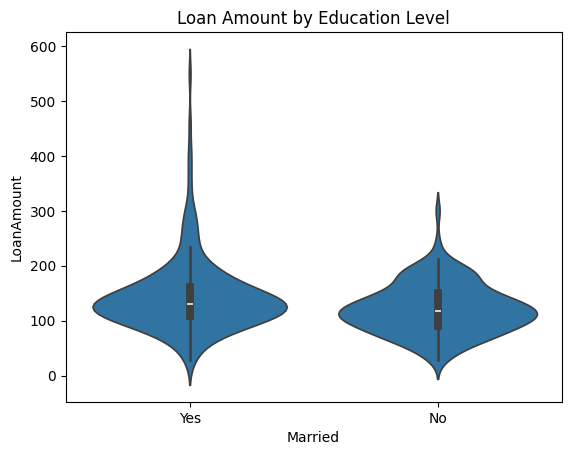

In [290]:
# Violin plot: LoanAmount vs Education
sns.violinplot(x='Married', y='LoanAmount', data=df)
plt.title('Loan Amount by Education Level')
plt.show()

Married applicants show a broader spread, suggesting they may apply for both higher and lower loan amounts.

Unmarried applicants mostly stick to mid-range loans.

Marital status could indirectly reflect joint financial planning, allowing for larger loan requests.

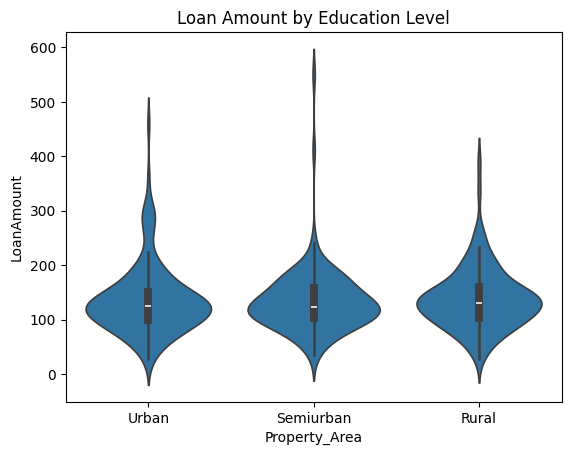

In [291]:
# Violin plot: LoanAmount vs Education
sns.violinplot(x='Property_Area', y='LoanAmount', data=df)
plt.title('Loan Amount by Education Level')
plt.show()

People are taking higher loan amount for Semi urban areas whereas slightly less for urban and comparitively lowest for Rural areas.
However, more people try for Urban area property.

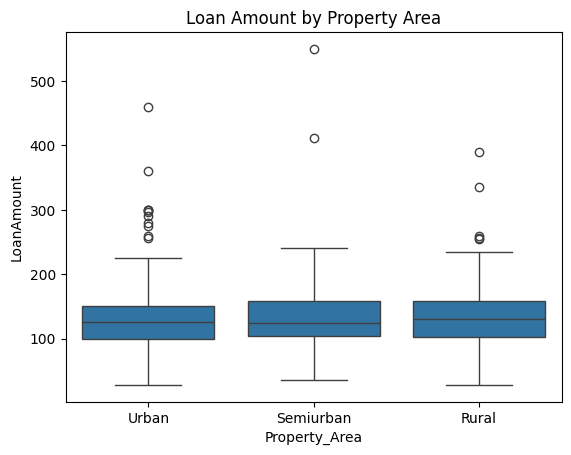

In [292]:
# Box plot: LoanAmount vs Property_Area
sns.boxplot(x='Property_Area', y='LoanAmount', data=df)
plt.title('Loan Amount by Property Area')
plt.show()

#  2.3 Multivariate Analysis

 # 1. Perform a correlation analysis to identify relationships between numeric variables
 # 2. Visualize correlations using a heatmap.


                   ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome           1.000000          -0.253653    0.486191   
CoapplicantIncome        -0.253653           1.000000    0.171433   
LoanAmount                0.486191           0.171433    1.000000   
Loan_Amount_Term          0.022508          -0.027435    0.091867   

                   Loan_Amount_Term  
ApplicantIncome            0.022508  
CoapplicantIncome         -0.027435  
LoanAmount                 0.091867  
Loan_Amount_Term           1.000000  


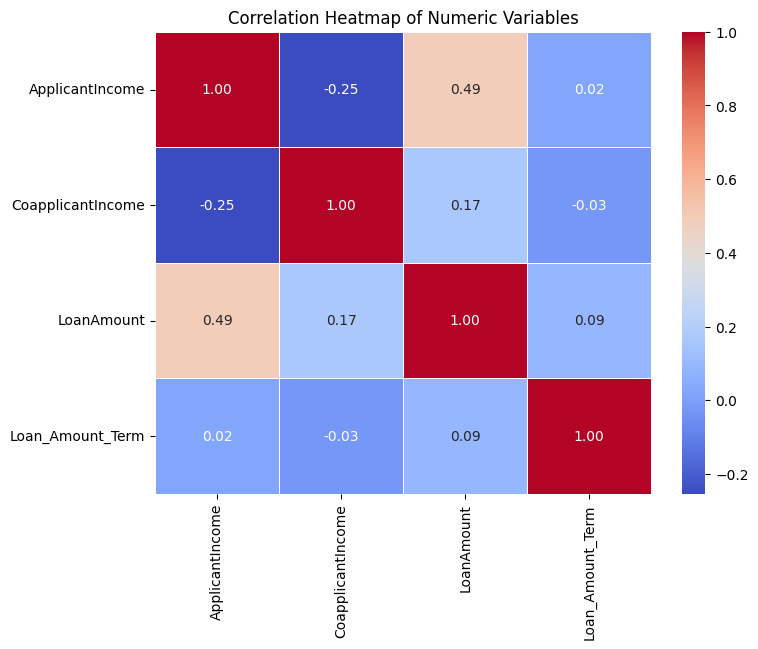

In [293]:
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Calculate correlation matrix
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

ApplicantIncome – LoanAmount	0.49	Moderate positive correlation—higher income often leads to higher loan amount.
CoapplicantIncome – LoanAmount	0.17	Weak correlation—coapplicant income has limited impact on loan amount.
LoanAmount – Loan_Amount_Term	0.09	No relationship almost 0—term length doesn’t influence loan amount.
Applicant vs Coapplicant Income	-0.25	Mild negative trend—if one earns more, the other tends to earn less (often 0).

# Create a stacked bar chart to show the distribution of categorical variables across multiple categories

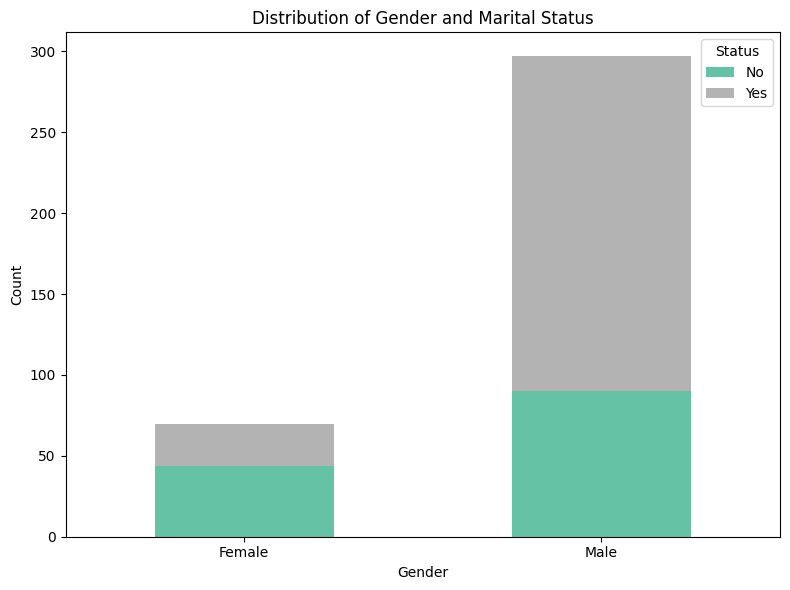

In [294]:
cross_tab = pd.crosstab(df['Gender'], df['Married'])

cross_tab.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set2')

plt.title('Distribution of Gender and Marital Status')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Males form the majority in the dataset.

Among males, the "Yes" (likely married) group is significantly larger than "No".

Females are fewer in number, and their marital status is more balanced, though slightly skewed towards "No".

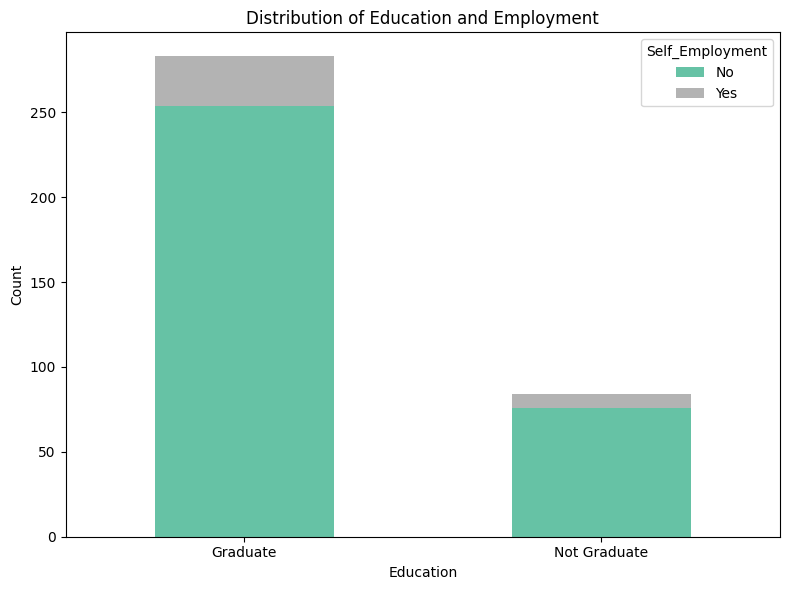

In [295]:
cross_tab = pd.crosstab(df['Education'], df['Self_Employed'])

cross_tab.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set2')

plt.title('Distribution of Education and Employment')
plt.xlabel('Education')
plt.ylabel('Count')
plt.legend(title='Self_Employment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A large number of graduates are not self-employed, indicating a strong preference or availability of salaried jobs among educated individuals.

Self-employment is more common among graduates than non-graduates, though still a minority.

To concludem the Home loan approval analysis reveals strong demographic and financial trends influencing loan preferences and approval. Strategic focus on income-based segmentation, credit history, and underserved groups can enhance financial inclusion and loan performance.



For Key Insights and Recommendations, Please refer to the presentation.